# real_groundtruth_downscale.ipynb

Reference validation notebook for the J-STARS paper:

**healpix-resample: a PSF-Aware HEALPix Resampling for Earth Observation Imagery**

## Why this notebook exists

The paper's two other real-data-adjacent checks each have a specific limit:

- The **UTM -> HEALPix -> UTM round trip** (`test-resample-paper.ipynb`) has no
  unblurred reference at all. It measures self-consistency with the input,
  not recovery of anything the method didn't already see.
- The **controlled synthetic-detector experiment** (`test-resample-paper.ipynb`,
  Esri World Imagery) has a real ground truth, but a *synthetic* one: the
  observation is generated by blurring that ground truth with the exact same
  Gaussian kernel the reconstruction operator then assumes. Recovering it is
  not, by itself, evidence that the method works on a real sensor's actual
  (non-Gaussian, unknown) response.

This notebook closes that gap using **only real Sentinel-2 data**: the real
10 m B04 band serves as both the source of a synthetic degradation *and* the
evaluation ground truth. Concretely, per scene:

1. Take the real, native 10 m Sentinel-2 B04 patch (`img_native`).
2. Degrade it to a synthetic coarse-resolution observation (`img_coarse`,
   native x `BLOCK`, 60 m by default) by a Gaussian blur followed by
   point-sampling (decimation) every `BLOCK`-th pixel -- deliberately not a
   block average; see the second revision note below for why.
3. Reconstruct a native-resolution field from `img_coarse` with the PSF-aware
   method (and with nearest/bilinear/bicubic/Richardson-Lucy baselines).
4. Compare every reconstruction directly against `img_native` -- a real,
   unsynthesized Sentinel-2 image.

## Revision note -- resolution gap and target HEALPix level

An earlier version of this notebook used a native 10 m -> 20 m degradation
(`BLOCK=2`) reconstructed onto the same level-20 HEALPix grid (~6.2 m cells)
used everywhere else in the paper for 10 m data. On real data that
configuration made the PSF-aware method the *worst* of all five methods on
two of four scenes, contradicting the qualitative impression from the
reconstructed images and spectra, which looked good. The likely reason: a
2x degradation followed by a request to resolve ~6 m structure (a ~3x
super-resolution factor relative to the coarse pixel) asks the operator to
extrapolate detail the degradation did not remove in a controlled way --
closer to hallucination risk than partial restoration, and not a fair test
of the method.

This version uses a much larger, more realistic resolution gap (`BLOCK=6`,
10 m -> 60 m, comparable to Sentinel-2's own 10 m vs. 60 m bands) and a
HEALPix target level chosen to give a *modest* refinement relative to the
coarse pixel (level 17, ~49.7 m cells) rather than reusing level 20 or 18,
whose ~6-25 m cells would ask for the same kind of unsupported extrapolation
at 60 m as before. `BLOCK`, `HEALPIX_LEVEL`, and the two assumed/true FWHM
values are all top-of-notebook constants -- see the configuration cell for
the exact reasoning behind each default and how to change them.

## Revision note -- degradation kernel shape (point-sampling, not block-average)

The first two versions of this notebook built `img_coarse` by Gaussian
blurring `img_native` and then **block-averaging** `BLOCK x BLOCK` pixels.
Block-averaging is a boxcar (square, non-circular) operation; compounded
with the Gaussian blur, the *true* degradation kernel is therefore not
circular, while `PSFResampler`'s weights (`w(d) = exp(-2 d^2 / s^2)`) are
strictly isotropic/circular by construction -- the package does not
currently support a non-circular or otherwise arbitrary kernel shape (it
would not be a large change to add one, but this notebook stays with the
Gaussian weights the rest of the paper uses). No choice of `RECON_FWHM_M`
can compensate for a squareness the operator has no way to represent, so
the block-average step was silently handicapping the PSF-aware method (and,
to a lesser extent, Richardson-Lucy, whose PSF is also modelled as
Gaussian) relative to the geometric baselines, which make no shape
assumption at all.

`degrade_to_coarse` now blurs once and then **point-samples** (decimates)
every `BLOCK`-th pixel, at the block centre, instead of averaging. The only
shaping of the signal is the preceding Gaussian blur, so the true
degradation kernel stays circular -- the fairest test achievable while
still keeping `DEGRADE_FWHM_M != RECON_FWHM_M` (a genuine, but now
shape-consistent, PSF mismatch rather than an exact inverse crime).


## 1. Imports and configuration

In [20]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import torch
import xarray as xr
import pyproj
import pystac_client
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

try:
    from healpix_resample import (
        PSFResampler, BicubicResampler, fwhm_to_scale, recommend_npt, cell_size_m,
    )
except Exception as exc:
    PSFResampler = BicubicResampler = fwhm_to_scale = recommend_npt = cell_size_m = None
    warnings.warn(f"Could not import healpix_resample: {exc}")

try:
    from skimage.restoration import richardson_lucy
except Exception as exc:
    richardson_lucy = None
    warnings.warn(f"Could not import richardson_lucy: {exc}")

# DATA_DIR is the SAME cache directory used by test-resample-paper.ipynb. If
# the four benchmark scenes were already fetched there, this notebook reuses
# those real Sentinel-2 patches instead of re-downloading them.
DATA_DIR  = Path("data")
FIG_DIR   = Path("figures")
TABLE_DIR = Path("tables")
for d in [DATA_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(exist_ok=True)

RANDOM_SEED = 1234
np.random.seed(RANDOM_SEED)

# -- Real data -----------------------------------------------------------------
MIRROR_BASE = ("https://grid4earth.s3.gra.io.cloud.ovh.net"
               "/public/eopf-mirror/sentinel-2-l2a/patches")
PATCH_SIZE   = 256          # native 10 m pixels per side, as fetched/cached
BAND         = "b04"        # Sentinel-2 red band, 10 m native
PIXEL_SIZE_M = 10.0
DEVICE       = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# -- Degradation model: real native truth -> synthetic coarse observation ------
# The coarse image is NOT a second real sensor: Sentinel-2 B04 has no native
# 60 m counterpart to use as an independent check. It is produced here by
# degrading the real 10 m band, so it is only as realistic as this model.
# What it buys over the paper's other experiments is that the *evaluation
# reference* (img_native) is real, unsynthesized Sentinel-2 imagery, not a
# texture the reconstruction operator has any special relationship to.
#
# BLOCK controls the resolution gap (native -> native*BLOCK). It must divide
# PATCH_SIZE's *working* crop evenly -- CENTRAL_SIZE below is derived
# automatically so this holds for any BLOCK, not just powers of two.
#
# BLOCK=6 (10 m -> 60 m) is the default: it mirrors the real 10 m vs. 60 m
# gap between Sentinel-2's own bands, and -- together with HEALPIX_LEVEL
# below -- avoids the earlier BLOCK=2 configuration's problem (see the title
# cell's revision note): asking the reconstruction to resolve far more
# structure than the degradation actually removed.
BLOCK = 6

# Largest multiple of BLOCK that does not exceed PATCH_SIZE, so decimation
# lands on a clean, regular grid for whatever BLOCK is chosen.
CENTRAL_SIZE = (PATCH_SIZE // BLOCK) * BLOCK

PIXEL_SIZE_COARSE_M = PIXEL_SIZE_M * BLOCK

# The degradation pipeline is:
#   1. Gaussian blur at DEGRADE_FWHM_M (the only shaping applied)
#   2. point-sample (decimate) every BLOCK-th pixel, at the block centre
# Step 2 is deliberately a point sample, NOT a block average. A block
# average is a boxcar (square, non-circular) operation; compounded with the
# Gaussian blur it would make the true degradation kernel non-circular,
# which PSFResampler's isotropic Gaussian weights (w(d)=exp(-2 d^2/s^2))
# have no way to represent regardless of how RECON_FWHM_M is tuned -- an
# unfair, baked-in disadvantage for the method under test, not a genuine
# reconstruction-quality difference. See the title cell's second revision
# note for the full reasoning.
# RECON_FWHM_M is still deliberately different from DEGRADE_FWHM_M (a real
# PSF mismatch, not an exact inverse crime) -- but both are now circular by
# construction, so that mismatch is a difference in *width*, not *shape*.
# Both FWHM values are derived from PIXEL_SIZE_COARSE_M (rather than fixed
# constants) so they scale automatically if BLOCK is changed; only the two
# ratios below encode a modelling assumption.
# DEGRADE_FWHM_M is set to a full pixel pitch (rather than a fraction of
# it, as in the block-averaged version) because the boxcar step is gone:
# without it, DEGRADE_FWHM_M is the *only* anti-aliasing the signal gets
# before decimation, so it needs to be wide enough on its own to suppress
# spatial frequencies above the new coarse-grid Nyquist limit.
DEGRADE_FWHM_M = 1.0 * PIXEL_SIZE_COARSE_M   # true (unknown-to-the-operator)
                                               # blur, applied before decimation

# -- Reconstruction (PSF-aware method under test) -------------------------------
# HEALPIX_LEVEL sets the target grid the field is reconstructed on. Level 20
# (~6.2 m cells, used everywhere else in this paper for 10 m data) or even
# level 18 (~24.9 m) would ask a 60 m source pixel for a 2.4x-10x
# super-resolution factor with no basis in the degradation actually applied
# here -- not partial restoration, just extrapolation past what the data can
# support (see the title cell's revision note). Level 17 (~49.7 m cells,
# printed below) gives a modest ~1.2x refinement relative to the 60 m pixel,
# comparable in spirit to the ~1.6x refinement level 20 gives relative to a
# 10 m pixel elsewhere in the paper. Change this constant to try others --
# the printed cell size below should stay well above the native 10 m pixel
# size divided by BLOCK if you want it to remain "modest" in the same sense.
HEALPIX_LEVEL = 18

RECON_FWHM_M = 1.25 * PIXEL_SIZE_COARSE_M    # assumed effective response;
                                               # 1.25x pixel pitch matches the
                                               # ratio used for the 10 m FWHM
                                               # elsewhere in the paper.
                                               # Deliberately not equal to
                                               # DEGRADE_FWHM_M above -- a
                                               # real PSF mismatch, not a
                                               # matched inverse-crime setup.
LAMBDA_COARSE = 0.01
MAX_ITER      = 14
THRESHOLD     = 0.1
READOUT_NPT   = 16           # BicubicResampler default, used only to read the
                              # reconstructed field out at the true native
                              # (10 m) pixel centres

if cell_size_m is not None:
    print(f"HEALPIX_LEVEL={HEALPIX_LEVEL}: target cell size "
          f"~= {cell_size_m(HEALPIX_LEVEL):.1f} m, vs. "
          f"{PIXEL_SIZE_COARSE_M:.0f} m coarse (degraded) pixel, vs. "
          f"{PIXEL_SIZE_M:.0f} m native pixel.")

# -- Richardson-Lucy baseline ----------------------------------------------------
RICHARDSON_LUCY_ITER = 100

# -- Evaluation -------------------------------------------------------------------
# Border excluded from every metric on each side, in native 10 m pixels, to
# avoid boundary artefacts from the Gaussian blur's reflect padding and from
# partially-supported HEALPix cells at the patch edge. Derived from
# RECON_FWHM_M (roughly 8 assumed-response widths) rather than fixed, so it
# scales automatically with the resampling kernel's reach.
BORDER_CROP_PX = int(round(8 * RECON_FWHM_M / PIXEL_SIZE_M))

CLASSICAL_METHODS = ["nearest", "linear", "cubic"]
CLASSICAL_LABELS = {"nearest": "Nearest", "linear": "Bilinear", "cubic": "Bicubic"}


def _cache_suffix():
    """Encode the parameters that change the *result* (not just plotting)
    into every intermediate cache filename, so switching BLOCK, HEALPIX_LEVEL,
    or RECON_FWHM_M -- e.g. to reproduce the earlier BLOCK=2/level-20
    configuration, or to try level 16 or 18 -- can never silently reuse a
    stale .npz from a different configuration. Cached files from a previous
    configuration are simply orphaned (harmless; delete data/*.npz to reclaim
    disk space).
    """
    return f"block{BLOCK}_lvl{HEALPIX_LEVEL}_fwhm{int(round(RECON_FWHM_M))}"


HEALPIX_LEVEL=18: target cell size ~= 24.9 m, vs. 60 m coarse (degraded) pixel, vs. 10 m native pixel.


## 2. Benchmark scenes

Same four scenes, pinned to the same GRID4EARTH-mirrored products, as `test-resample-paper.ipynb` -- so this notebook draws on the same real Sentinel-2 patches used everywhere else in the paper.

In [21]:
benchmark_coordinates = {
    "urban": {
        "location": "Paris, France",
        "wgs84": {"lat": 48.8566, "lon": 2.3522},
        "recommended_date": "2026-05-01/2026-05-30",
        "product_id": "S2B_MSIL2A_20260527T105619_N0512_R094_T31UDQ_20260527T133135",
        "cloud": 20,
    },
    "water": {
        "location": "Lake Geneva, Switzerland",
        "wgs84": {"lat": 46.4983, "lon": 6.6327},
        "recommended_date": "2026-06-01/2026-06-24",
        "product_id": "S2A_MSIL2A_20260624T103041_N0512_R108_T32TLS_20260624T182910",
        "cloud": 20,
    },
    "forest": {
        "location": "Black Forest, Germany",
        "wgs84": {"lat": 48.265, "lon": 8.016},
        "recommended_date": "2026-07-01/2026-07-31",
        "product_id": "S2A_MSIL2A_20260704T102701_N0512_R108_T32UMU_20260704T170718",
        "cloud": 20,
    },
    "agriculture": {
        "location": "Beauce plains, France",
        "wgs84": {"lat": 48.258, "lon": 1.499},
        "recommended_date": "2026-06-01/2026-06-30",
        "product_id": "S2B_MSIL2A_20260623T104619_N0512_R051_T31UCP_20260623T132606",
        "cloud": 20,
    },
}


## 3. Sentinel-2 fetch utilities

Self-contained copy of `test-resample-paper.ipynb`'s extraction logic, unchanged, so this notebook can run standalone. Because the cache filename convention (`DATA_DIR / f"{scene}_data.zarr"`) is identical, if that notebook already populated `data/`, nothing is re-downloaded here.

In [22]:
def _crs_of(obj):
    """CRS of an EOPF product or a cached patch.

    `obj.crs_code` is not provided by xarray-eopf 0.3.0, and the metadata key
    is `horizontal_CRS_code` (capital CRS), not `horizontal_crs_code`. The CF
    grid-mapping coordinate is the stable place to look, so prefer it.
    """
    try:
        return pyproj.CRS.from_wkt(obj.spatial_ref.attrs["crs_wkt"])
    except Exception:
        try:
            meta = getattr(obj, "attrs", {}).get("other_metadata", {})
            return pyproj.CRS.from_user_input(meta["horizontal_CRS_code"])
        except Exception:
            meta = getattr(obj, "attrs", {}).get("other_metadata", {})
            return pyproj.CRS.from_user_input(meta["horizontal_crs_code"])


def _add_latlon(ds, transformer):
    xx, yy = np.meshgrid(ds.x.values, ds.y.values)
    lon, lat = transformer.transform(xx, yy)
    ds = ds.assign_coords(longitude=(["y", "x"], lon), latitude=(["y", "x"], lat))
    return ds


def extract_bench_data(scene, patch_size=PATCH_SIZE, force=False, coords=None, band=None):
    """Fetch (or load from cache) the native 10 m patch for one scene.

    `coords` defaults to `benchmark_coordinates[scene]`. Pass it explicitly to
    fetch a one-off location without registering it in `benchmark_coordinates`.
    """
    if band is None:
        band = BAND

    xr.set_options(keep_attrs=True, display_expand_attrs=False)
    catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
    path = DATA_DIR / f"{scene}_data.zarr"
    if path.exists() and not force:
        try:
            import zarr as _zarr
            _a = _zarr.open_group(str(path), mode="r").attrs.asdict()
            if _a.get("source_item_id"):
                print(f"[{scene}] cached  <- {_a['source_item_id']}"
                      f"  ({_a.get('source_datetime', '?')},"
                      f" cloud {_a.get('source_cloud_cover', '?')}%)")
            else:
                print(f"[{scene}] cached  <- provenance not recorded "
                      f"(cache predates source_item_id; delete it to refresh)")
        except Exception as _exc:
            print(f"[{scene}] cached  <- could not read provenance: {_exc}")
        return
    coords = benchmark_coordinates[scene] if coords is None else coords
    lat0, lon0 = coords["wgs84"]["lat"], coords["wgs84"]["lon"]

    pinned = coords.get("product_id")
    if pinned:
        try:
            import fsspec
            _ds = xr.open_zarr(
                fsspec.get_mapper(f"{MIRROR_BASE}/{pinned}.zarr"), consolidated=True
            )
            _ds.to_zarr(path, mode="w")
            print(f"[{scene}] mirror  <- {pinned}"
                  f"  (cloud {_ds.attrs.get('source_cloud_cover', '?')}%)")
            return
        except Exception as exc:
            print(f"[{scene}] mirror unavailable ({type(exc).__name__}), "
                  f"falling back to the STAC search: {str(exc)[:70]}")

    items = list(catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=[lon0 - 0.05, lat0 - 0.05, lon0 + 0.05, lat0 + 0.05],
        datetime=coords["recommended_date"],
        query={"eo:cloud_cover": {"lt": coords["cloud"]}},
    ).get_all_items())
    if not items:
        raise RuntimeError(f"No items for {scene}")
    item = items[0]

    _props = item.properties
    print(f"[{scene}] {len(items)} product(s) matched; using {item.id}"
          f"  ({_props.get('datetime', '?')},"
          f" cloud {_props.get('eo:cloud_cover', '?')}%)")
    if len(items) > 1:
        print(f"[{scene}]   others: {', '.join(i.id for i in items[1:4])}"
              f"{' ...' if len(items) > 4 else ''}")

    ds = xr.open_dataset(
        item.assets["product"].href,
        engine="eopf-zarr",
        resolution=10,
        variables=[band],
        chunks={},
    )

    try:
        src_crs = pyproj.CRS.from_wkt(ds.spatial_ref.attrs["crs_wkt"])
    except Exception:
        try:
            src_crs = pyproj.CRS.from_user_input(
                ds.attrs["other_metadata"]["horizontal_CRS_code"]
            )
        except Exception:
            src_crs = pyproj.CRS.from_user_input(
                ds.attrs["other_metadata"]["horizontal_crs_code"]
            )
    transformer = pyproj.Transformer.from_crs(
        src_crs, pyproj.CRS.from_epsg(4326), always_xy=True
    )

    _fwd = pyproj.Transformer.from_crs(
        pyproj.CRS.from_epsg(4326), _crs_of(ds), always_xy=True
    )
    x_c, y_c = _fwd.transform(lon0, lat0)
    half = patch_size // 2 * 10
    ds_patch = ds.sel(
        x=slice(x_c - half, x_c + half),
        y=slice(y_c + half, y_c - half),
    )
    ds_patch = _add_latlon(ds_patch, transformer)
    ds_patch.attrs["source_item_id"] = item.id
    ds_patch.attrs["source_collection"] = "sentinel-2-l2a"
    ds_patch.attrs["source_stac_endpoint"] = "https://stac.core.eopf.eodc.eu"
    ds_patch.attrs["source_datetime"] = str(_props.get("datetime", ""))
    ds_patch.attrs["source_cloud_cover"] = str(_props.get("eo:cloud_cover", ""))
    ds_patch.to_zarr(path, mode="w")


## 4. Download or load scenes (real, native 10 m)

In [23]:
FORCE_DOWNLOAD = False
for scene in benchmark_coordinates:
    try:
        extract_bench_data(scene, force=FORCE_DOWNLOAD)
        print(f"[OK] {scene}")
    except Exception as exc:
        print(f"[WARN] {scene}: {exc}")


[urban] cached  <- S2B_MSIL2A_20260527T105619_N0512_R094_T31UDQ_20260527T133135  (2026-05-27T10:56:19.024000Z, cloud 0.00289%)
[OK] urban
[water] cached  <- S2A_MSIL2A_20260624T103041_N0512_R108_T32TLS_20260624T182910  (2026-06-24T10:30:41.024000Z, cloud 2.696484%)
[OK] water
[forest] cached  <- S2A_MSIL2A_20260724T102701_N0512_R108_T32UMU_20260724T171410  (2026-07-24T10:27:01.024000Z, cloud 0.078397%)
[OK] forest
[agriculture] cached  <- S2A_MSIL2A_20260623T105711_N0512_R094_T31UCP_20260623T173411  (2026-06-23T10:57:11.024000Z, cloud 1.064157%)
[OK] agriculture


## 5. Common utilities: loading, UTM axes, block-reduce

In [24]:
def fill_nan_with_mean(img):
    img = np.asarray(img, dtype=np.float32).copy()
    mask = np.isfinite(img)
    if not mask.any():
        raise ValueError("Image contains no finite pixels.")
    img[~mask] = np.nanmean(img)
    return img


def load_scene_patch(scene_name):
    path = DATA_DIR / f"{scene_name}_data.zarr"
    dt = xr.open_datatree(path, engine="zarr", consolidated=False, chunks={})
    da = dt[BAND]
    img = fill_nan_with_mean(da.values)
    lon = da["longitude"].values.astype(np.float64)
    lat = da["latitude"].values.astype(np.float64)
    return img, lon, lat, da


def central_crop(img, size=CENTRAL_SIZE):
    ny, nx = img.shape
    cy, cx = ny // 2, nx // 2
    h = size // 2
    return img[cy - h:cy + h, cx - h:cx + h]


def get_utm_axes(da, central_size=CENTRAL_SIZE):
    """1-D UTM x and y axes for the central crop of a DataArray."""
    x_full = da.x.values
    y_full = da.y.values
    nx, ny = x_full.size, y_full.size
    cx, cy = nx // 2, ny // 2
    h = central_size // 2
    x0 = x_full[cx - h:cx + h]
    y0 = y_full[cy - h:cy + h]
    return x0, y0


def decimate_2d(arr, block=BLOCK, offset=None):
    """Point-sample every `block`-th row/column of a 2-D array, at a fixed
    sub-pixel offset (defaults to the block centre, `block // 2`).

    Deliberately NOT a block average: averaging mixes in a boxcar (square,
    non-circular) component on top of whatever blur was already applied,
    which a circular-kernel resampler (PSFResampler) has no way to
    represent. Decimating a already-blurred array keeps the *shape* of the
    true degradation kernel equal to the shape of that blur alone -- see the
    degradation-model markdown cell below.
    """
    if offset is None:
        offset = block // 2
    return arr[offset::block, offset::block]


def decimate_1d(arr, block=BLOCK, offset=None):
    """1-D analogue of decimate_2d, for UTM axis arrays: the geolocation of
    each decimated sample must be the true location of the pixel that was
    point-sampled, not a block-averaged position."""
    if offset is None:
        offset = block // 2
    return arr[offset::block]


def crop_border(img, border=BORDER_CROP_PX):
    if border <= 0:
        return img
    return img[border:-border, border:-border]


## 6. Degradation model: real native truth -> synthetic coarse observation

Gaussian blur once, then point-sample (decimate) -- not block-average -- so the true degradation kernel stays circular, matching the shape `PSFResampler`'s Gaussian weights assume (see the configuration cell and the title cell's second revision note for why this matters). `build_coarse_grid` returns the real native-resolution truth, its geolocation, and the corresponding synthetic coarse observation with matching geolocation, all derived from a *single* real cached patch.

In [25]:
def _fwhm_to_gauss_sigma_px(fwhm_m, pixel_size_m=PIXEL_SIZE_M):
    """Standard Gaussian FWHM -> sigma (pixels), for scipy.ndimage.gaussian_filter.

    NOTE: this is the ordinary sigma = FWHM / (2*sqrt(2 ln 2)) convention --
    NOT the healpix_resample package's own `s = FWHM / sqrt(2 ln 2)` scale
    (see healpix_resample.psf_geometry's module docstring). The two are
    unrelated conventions used in two different places in this notebook and
    must not be swapped: this one feeds scipy's blur, `fwhm_to_scale()`
    (imported from healpix_resample) feeds the PSFResampler kernel below.
    """
    sigma_m = fwhm_m / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    return sigma_m / pixel_size_m


def degrade_to_coarse(img_native, fwhm_m=DEGRADE_FWHM_M, block=BLOCK):
    """Real native-resolution Sentinel-2 B04 -> synthetic coarse observation
    (native x `block`, 60 m at the current default).

    Gaussian blur (the only shaping applied) followed by point-sampling
    (decimation) every `block`-th pixel -- deliberately NOT a block average
    (see the configuration cell and the title cell's second revision note).
    The true degradation kernel is therefore a plain, circular Gaussian at
    `fwhm_m`, distinct in *width* from the operator's assumed `RECON_FWHM_M`
    but not in *shape* -- recovering `img_native` is still not a matter of
    inverting the exact process that generated `img_coarse` (the widths
    differ), but the mismatch is now one PSFResampler's kernel family could
    in principle represent, rather than one it structurally cannot.
    """
    sigma_px = _fwhm_to_gauss_sigma_px(fwhm_m)
    blurred = gaussian_filter(img_native, sigma=sigma_px, mode="reflect")
    return decimate_2d(blurred, block=block)


def build_coarse_grid(scene_name):
    """Real native-resolution truth + geolocation, and the synthetic coarse
    observation + geolocation, for one scene."""
    img_n, lon_n, lat_n, da = load_scene_patch(scene_name)
    img_n = central_crop(img_n)
    lon_n = central_crop(lon_n)
    lat_n = central_crop(lat_n)

    img_c = degrade_to_coarse(img_n)
    lon_c = decimate_2d(lon_n, block=BLOCK)
    lat_c = decimate_2d(lat_n, block=BLOCK)

    x_n, y_n = get_utm_axes(da)
    x_c = decimate_1d(x_n, block=BLOCK)
    y_c = decimate_1d(y_n, block=BLOCK)

    return dict(img_native=img_n, lon_native=lon_n, lat_native=lat_n,
                x_native=x_n, y_native=y_n,
                img_coarse=img_c, lon_coarse=lon_c, lat_coarse=lat_c,
                x_coarse=x_c, y_coarse=y_c, da=da)


## 7. PSF-aware reconstruction (matched effective response)

`PSFResampler` is built from the coarse degraded samples and solves for a HEALPix field at `HEALPIX_LEVEL`. To evaluate against the real native (10 m) grid -- a different, denser set of points than the operator's own coarse samples -- `sample_healpix_field_at` builds a *second*, purely-interpolating resampler (`BicubicResampler`) whose sample points are the true native-pixel centres and whose output cell space is restricted to the first operator's retained cells via `out_cell_ids`. Calling `.invert()` on that second instance reads the reconstructed field out at the native centres with no further deconvolution -- exactly the composition `out_cell_ids` is designed for in this package.

In [26]:
def sample_healpix_field_at(cell_ids_src, cell_data_src, lon_q, lat_q, level,
                             device=DEVICE, npt=READOUT_NPT, threshold=THRESHOLD):
    """Interpolate a HEALPix cell-space field at arbitrary query points.

    `cell_ids_src`/`cell_data_src` is the (cell_ids, cell_data) pair returned
    by a PSFResampler's `.resample()`, defined only on the sparse set of
    HEALPix cells that operator retained. To read the reconstructed field out
    at *different* points than the operator's own samples, build a second
    resampler whose own sample points are the query points and whose output
    cell space is restricted to `cell_ids_src` via `out_cell_ids`, then call
    `.invert()` on it -- `.invert()` uses that instance's own adjoint operator
    MT, i.e. a bicubic-kernel interpolation of a HEALPix-cell field at its
    sample points, which is exactly what is needed here.
    """
    readout = BicubicResampler(
        lon_deg=np.asarray(lon_q).reshape(-1),
        lat_deg=np.asarray(lat_q).reshape(-1),
        level=level, out_cell_ids=cell_ids_src, Npt=npt,
        threshold=threshold, device=device, verbose=False,
    )
    dest_ids = readout.get_cell_ids()
    pos = {int(c): i for i, c in enumerate(np.asarray(cell_ids_src))}
    sel = np.array([pos[int(c)] for c in dest_ids], dtype=np.int64)
    aligned = np.asarray(cell_data_src)[sel]
    out = readout.invert(aligned)
    return np.asarray(out)


def reconstruct_psf_aware(scene_name, force=False):
    out_npz = DATA_DIR / f"{scene_name}_real_downscale_psf_aware_{_cache_suffix()}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    if PSFResampler is None:
        raise ImportError("PSFResampler is not available. Install healpix-resample.")

    g = build_coarse_grid(scene_name)

    scale_m = fwhm_to_scale(RECON_FWHM_M)
    npt = recommend_npt(scale_m, HEALPIX_LEVEL)["npt"]

    t0 = time.time()
    resampler = PSFResampler(
        lon_deg=g["lon_coarse"].reshape(-1), lat_deg=g["lat_coarse"].reshape(-1),
        level=HEALPIX_LEVEL, sigma_m=scale_m, Npt=npt,
        threshold=THRESHOLD, device=DEVICE, verbose=False,
    )
    build_time = time.time() - t0

    t1 = time.time()
    res = resampler.resample(g["img_coarse"].reshape(-1), lam=LAMBDA_COARSE, max_iter=MAX_ITER)
    solve_time = time.time() - t1

    t2 = time.time()
    rec_flat = sample_healpix_field_at(
        res.cell_ids, res.cell_data, g["lon_native"], g["lat_native"], HEALPIX_LEVEL,
    )
    readout_time = time.time() - t2

    rec_native = np.asarray(rec_flat).reshape(g["img_native"].shape)

    np.savez_compressed(
        out_npz, scene=scene_name,
        truth10=g["img_native"].astype(np.float32),
        degraded20=g["img_coarse"].astype(np.float32),
        reconstructed10=rec_native.astype(np.float32),
        build_time=build_time, solve_time=solve_time, readout_time=readout_time,
    )
    return dict(np.load(out_npz, allow_pickle=True))


## 8. Classical geometric baselines (nearest / bilinear / bicubic)

Purely geometric upsampling of the coarse observation onto the true native grid, with no spatial-response model -- the same role these baselines play everywhere else in the paper.

In [27]:
def _axes_ascending(y_ax, x_ax, img):
    """RegularGridInterpolator requires ascending axes; UTM y is usually
    descending (north-up raster). Flip whichever axis needs it."""
    if y_ax[0] > y_ax[-1]:
        y_ax, img = y_ax[::-1], img[::-1, :]
    if x_ax[0] > x_ax[-1]:
        x_ax, img = x_ax[::-1], img[:, ::-1]
    return y_ax, x_ax, img


def reconstruct_classical(scene_name, method="linear", force=False):
    out_npz = DATA_DIR / f"{scene_name}_real_downscale_classical_{method}_{_cache_suffix()}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    g = build_coarse_grid(scene_name)
    y_ax, x_ax, img_ax = _axes_ascending(g["y_coarse"], g["x_coarse"], g["img_coarse"])

    interp = RegularGridInterpolator((y_ax, x_ax), img_ax, method=method,
                                      bounds_error=False, fill_value=None)
    yy_n, xx_n = np.meshgrid(g["y_native"], g["x_native"], indexing="ij")
    rec_native = interp(np.stack([yy_n.ravel(), xx_n.ravel()], axis=-1)).reshape(g["img_native"].shape)

    np.savez_compressed(
        out_npz, scene=scene_name, method=method,
        truth10=g["img_native"].astype(np.float32),
        reconstructed10=rec_native.astype(np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


## 9. Richardson-Lucy two-stage baseline

Deconvolve the coarse observation with the same assumed Gaussian response used by the PSF-aware operator (`RECON_FWHM_M`), then bicubically upsample to the true native grid -- the same two-stage structure used for this baseline throughout the paper.

In [28]:
def reconstruct_richardson_lucy(scene_name, force=False):
    out_npz = DATA_DIR / f"{scene_name}_real_downscale_richardson_lucy_{_cache_suffix()}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))
    if richardson_lucy is None:
        raise ImportError("scikit-image richardson_lucy is not available.")

    g = build_coarse_grid(scene_name)
    img_c = g["img_coarse"]

    lo, hi = np.percentile(img_c, [0.5, 99.5])
    hi = max(hi, lo + 1e-6)
    img01 = np.clip((img_c - lo) / (hi - lo), 0, 1)

    sigma_px = _fwhm_to_gauss_sigma_px(RECON_FWHM_M, pixel_size_m=PIXEL_SIZE_COARSE_M)
    radius = max(1, int(np.ceil(4 * sigma_px)))
    ax = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(ax, ax)
    psf = np.exp(-0.5 * (xx ** 2 + yy ** 2) / sigma_px ** 2)
    psf /= psf.sum()

    deconv01 = richardson_lucy(img01, psf, num_iter=RICHARDSON_LUCY_ITER, clip=False)
    deconv_c = deconv01 * (hi - lo) + lo

    y_ax, x_ax, img_ax = _axes_ascending(g["y_coarse"], g["x_coarse"], deconv_c)
    interp = RegularGridInterpolator((y_ax, x_ax), img_ax, method="cubic",
                                      bounds_error=False, fill_value=None)
    yy_n, xx_n = np.meshgrid(g["y_native"], g["x_native"], indexing="ij")
    rec_native = interp(np.stack([yy_n.ravel(), xx_n.ravel()], axis=-1)).reshape(g["img_native"].shape)

    np.savez_compressed(
        out_npz, scene=scene_name,
        truth10=g["img_native"].astype(np.float32),
        reconstructed10=rec_native.astype(np.float32),
    )
    return dict(np.load(out_npz, allow_pickle=True))


## 10. Metrics and spectral utilities

All metrics are computed after `crop_border` removes a margin affected by the Gaussian blur's reflect-padding and by partially-supported HEALPix cells at the patch edge.

In [29]:
def compute_metrics(truth, estimate, scene, method):
    t = crop_border(np.asarray(truth, dtype=np.float64))
    e = crop_border(np.asarray(estimate, dtype=np.float64))
    mask = np.isfinite(t) & np.isfinite(e)
    tv, ev = t[mask], e[mask]
    err = ev - tv

    rmse = float(np.sqrt(mean_squared_error(tv, ev)))
    mae = float(mean_absolute_error(tv, ev))
    bias = float(np.mean(err))
    corr = float(np.corrcoef(tv, ev)[0, 1]) if tv.size > 1 else np.nan
    dr = float(np.nanmax(t) - np.nanmin(t))
    psnr = (float("inf") if rmse == 0
            else float(20 * np.log10(dr / rmse)) if dr > 0 else np.nan)

    t_s = np.where(np.isfinite(t), t, np.nanmean(t))
    e_s = np.where(np.isfinite(e), e, np.nanmean(e))
    data_range = float(np.nanmax(t_s) - np.nanmin(t_s))
    ssim_val = float(ssim(t_s, e_s, data_range=data_range)) if data_range > 0 else np.nan

    return dict(scene=scene, method=method, rmse=rmse, mae=mae, bias=bias,
                corr=corr, psnr=psnr, ssim=ssim_val)


def prepare_for_psd(img, normalize=True, apodize=True):
    arr = np.asarray(img, dtype=np.float64)
    arr = np.where(np.isfinite(arr), arr, np.nanmean(arr))
    if normalize:
        p1, p99 = np.nanpercentile(arr, [1, 99])
        if p99 > p1:
            arr = np.clip((arr - p1) / (p99 - p1), 0, 1)
    arr = arr - np.mean(arr)
    if apodize:
        wy = np.hanning(arr.shape[0])
        wx = np.hanning(arr.shape[1])
        arr = arr * np.outer(wy, wx)
    return arr


def psd1d_numpy(img, pixel_size_m=PIXEL_SIZE_M):
    arr = prepare_for_psd(img)
    ft = np.fft.fftshift(np.fft.fft2(arr))
    psd2 = np.abs(ft) ** 2
    ny, nx = arr.shape
    yy, xx = np.indices((ny, nx))
    rr = np.sqrt((xx - nx // 2) ** 2 + (yy - ny // 2) ** 2).astype(np.int64)
    max_r = min(nx, ny) // 2
    psd_sum = np.bincount(rr.ravel(), weights=psd2.ravel(), minlength=max_r + 1)[:max_r + 1]
    psd_cnt = np.bincount(rr.ravel(), minlength=max_r + 1)[:max_r + 1]
    psd_mean = psd_sum / np.maximum(psd_cnt, 1)
    freq = np.arange(max_r + 1) / (max_r * 2 * pixel_size_m)
    return freq, psd_mean


## 11. Run everything

In [30]:
def run_all(force=False):
    rows = []
    for scene in benchmark_coordinates:
        try:
            d = reconstruct_psf_aware(scene, force=force)
            rows.append(compute_metrics(d["truth10"], d["reconstructed10"], scene, "psf_aware"))
        except Exception as exc:
            print(f"[WARN] PSF-aware failed for {scene}: {exc}")

        for method in CLASSICAL_METHODS:
            try:
                d = reconstruct_classical(scene, method=method, force=force)
                rows.append(compute_metrics(d["truth10"], d["reconstructed10"], scene, f"classical_{method}"))
            except Exception as exc:
                print(f"[WARN] classical {method} failed for {scene}: {exc}")

        try:
            d = reconstruct_richardson_lucy(scene, force=force)
            rows.append(compute_metrics(d["truth10"], d["reconstructed10"], scene, "richardson_lucy"))
        except Exception as exc:
            print(f"[WARN] Richardson-Lucy failed for {scene}: {exc}")

    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / "real_groundtruth_downscale_metrics.csv", index=False)
    return df


metrics_df = run_all(force=False)
metrics_df


,scene,method,rmse,mae,bias,corr,psnr,ssim
0,urban,psf_aware,0.046094,0.029124,-0.000057,0.605206,30.998539,0.718478
1,urban,classical_nearest,0.046857,0.028413,-0.000139,0.557362,30.856017,0.702596
2,urban,classical_linear,0.046541,0.028210,-0.000038,0.577527,30.914667,0.706603
3,urban,classical_cubic,0.045301,0.027539,-0.000056,0.604269,31.149337,0.715199
4,urban,richardson_lucy,0.044808,0.026578,-0.000463,0.607064,31.244374,0.732161
5,water,psf_aware,0.001106,0.000565,-0.000017,0.632299,17.812230,0.223105
6,water,classical_nearest,0.000602,0.000475,0.000013,0.851514,23.098972,0.199035
7,water,classical_linear,0.000868,0.000505,0.000047,0.716649,19.915056,0.197094
8,water,classical_cubic,0.000798,0.000496,0.000023,0.752406,20.647026,0.201505
9,water,richardson_lucy,0.000747,0.000499,0.000003,0.778620,21.218350,0.214765


### Results table (paper format)

In [31]:
def format_table(df):
    methods = ["psf_aware"] + [f"classical_{m}" for m in CLASSICAL_METHODS] + ["richardson_lucy"]
    labels = {
        "psf_aware": "PSF-aware",
        "classical_nearest": "Nearest-neighbor",
        "classical_linear": "Bilinear",
        "classical_cubic": "Bicubic",
        "richardson_lucy": "Richardson-Lucy",
    }
    records = []
    for scene in benchmark_coordinates:
        row = {"Scene": scene}
        for m in methods:
            sub = df[(df["scene"] == scene) & (df["method"] == m)]
            if not sub.empty:
                row[f"{labels[m]} RMSE"] = sub.iloc[0]["rmse"]
                row[f"{labels[m]} SSIM"] = sub.iloc[0]["ssim"]
            else:
                row[f"{labels[m]} RMSE"] = np.nan
                row[f"{labels[m]} SSIM"] = np.nan
        records.append(row)
    table = pd.DataFrame(records)
    table.to_csv(TABLE_DIR / "real_groundtruth_downscale_table.csv", index=False)
    return table


format_table(metrics_df)


,Scene,PSF-aware RMSE,PSF-aware SSIM,Nearest-neighbor RMSE,Nearest-neighbor SSIM,Bilinear RMSE,Bilinear SSIM,Bicubic RMSE,Bicubic SSIM,Richardson-Lucy RMSE,Richardson-Lucy SSIM
0,urban,0.046094,0.718478,0.046857,0.702596,0.046541,0.706603,0.045301,0.715199,0.044808,0.732161
1,water,0.001106,0.223105,0.000602,0.199035,0.000868,0.197094,0.000798,0.201505,0.000747,0.214765
2,forest,0.021110,0.578413,0.023362,0.518697,0.021908,0.548815,0.019980,0.588672,0.018426,0.624575
3,agriculture,0.019301,0.687918,0.022341,0.650000,0.020518,0.692571,0.018261,0.725316,0.016002,0.748774


### Figure -- qualitative panels per scene

Each row is a scene; each column shows one method's reconstruction against the real native (10 m) truth and the synthetic coarse observation actually fed to every method.

(132, 132)
(42, 42)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(42, 42)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(42, 42)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(42, 42)
(132, 132)
(132, 132)
(132, 132)
(132, 132)
(132, 132)


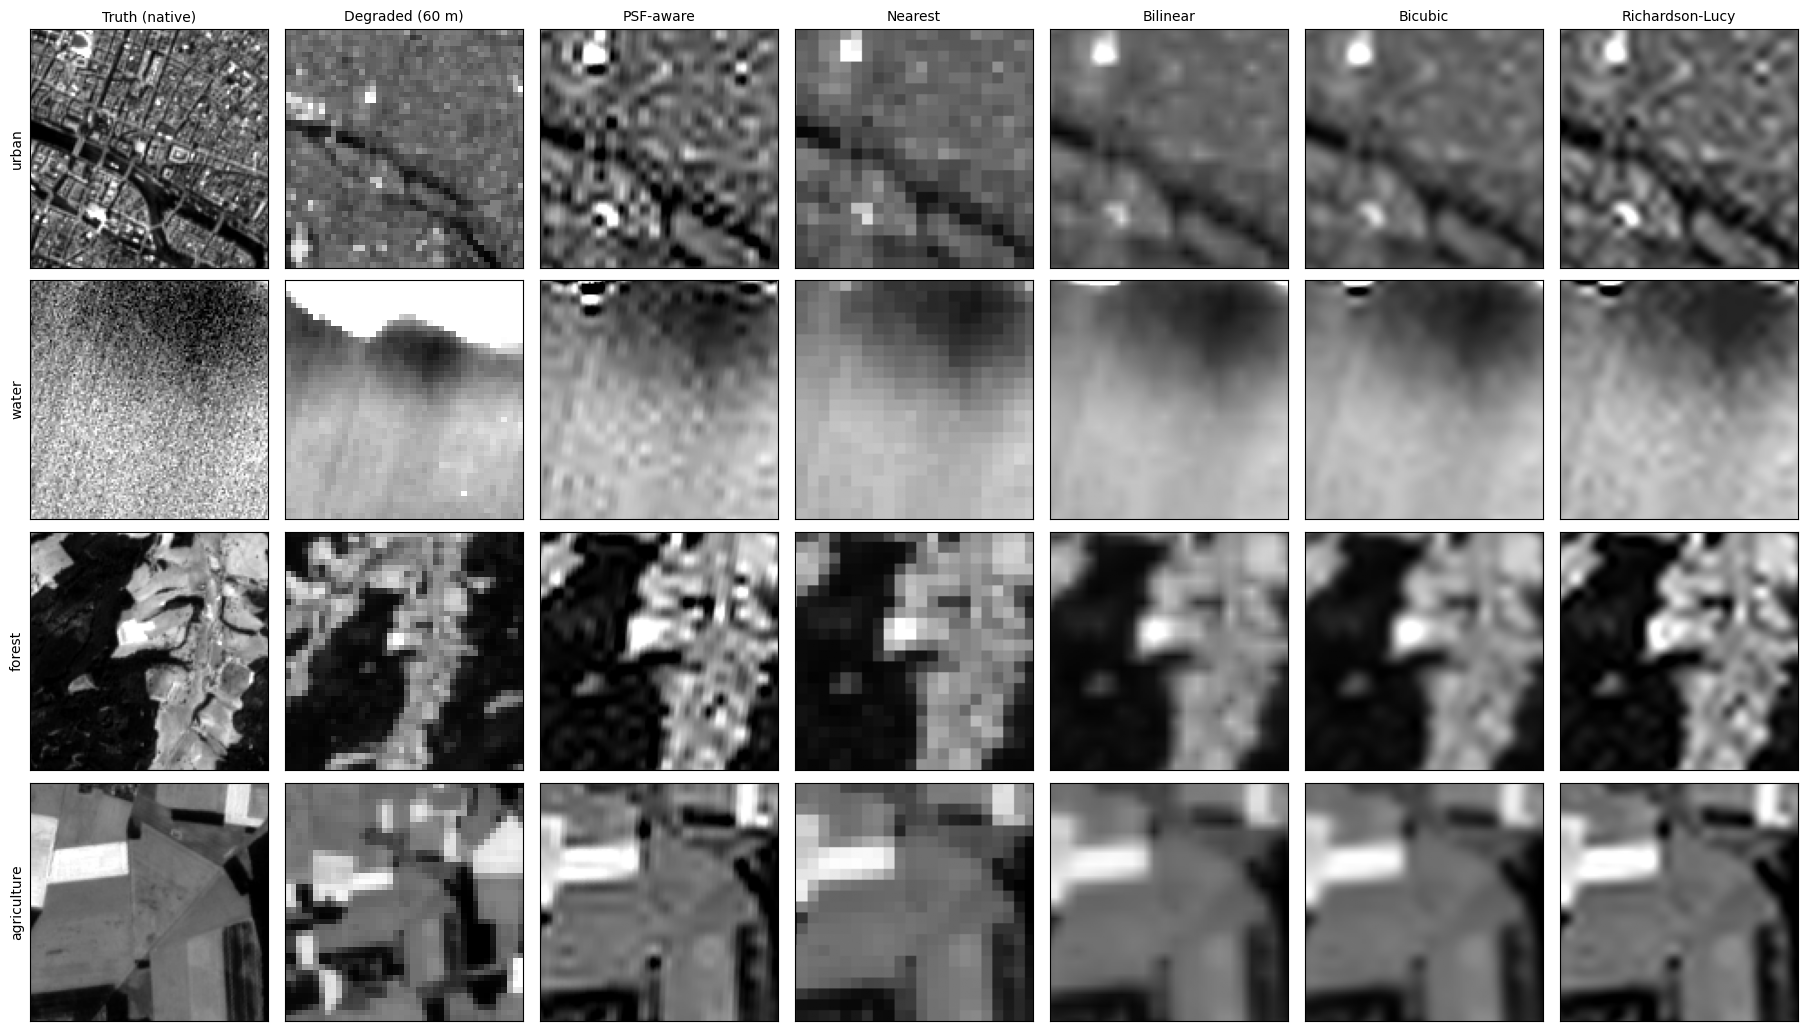

In [32]:
def plot_panels(force=False):
    scenes = list(benchmark_coordinates.keys())
    col_labels = ["Truth (native)", f"Degraded ({PIXEL_SIZE_COARSE_M:.0f} m)", "PSF-aware", "Nearest", "Bilinear", "Bicubic", "Richardson-Lucy"]
    fig, axes = plt.subplots(len(scenes), len(col_labels), figsize=(2.6 * len(col_labels), 2.6 * len(scenes)))
    if len(scenes) == 1:
        axes = axes[np.newaxis, :]

    for r, scene in enumerate(scenes):
        psf_d = reconstruct_psf_aware(scene, force=force)
        truth = crop_border(psf_d["truth10"])
        vmin, vmax = np.nanpercentile(truth, [1, 99])

        panels = [truth, psf_d["degraded20"], crop_border(psf_d["reconstructed10"])]
        for method in CLASSICAL_METHODS:
            cl = reconstruct_classical(scene, method=method, force=force)
            panels.append(crop_border(cl["reconstructed10"]))
        rl = reconstruct_richardson_lucy(scene, force=force)
        panels.append(crop_border(rl["reconstructed10"]))

        for c, img in enumerate(panels):
            ax = axes[r, c]
            print(img.shape)
            ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0:
                ax.set_title(col_labels[c], fontsize=10)
            if c == 0:
                ax.set_ylabel(scene, fontsize=10)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "real_groundtruth_downscale_panels.pdf", dpi=200)
    plt.show()


plot_panels(force=False)


### Figure -- spectral comparison against the real native ground truth

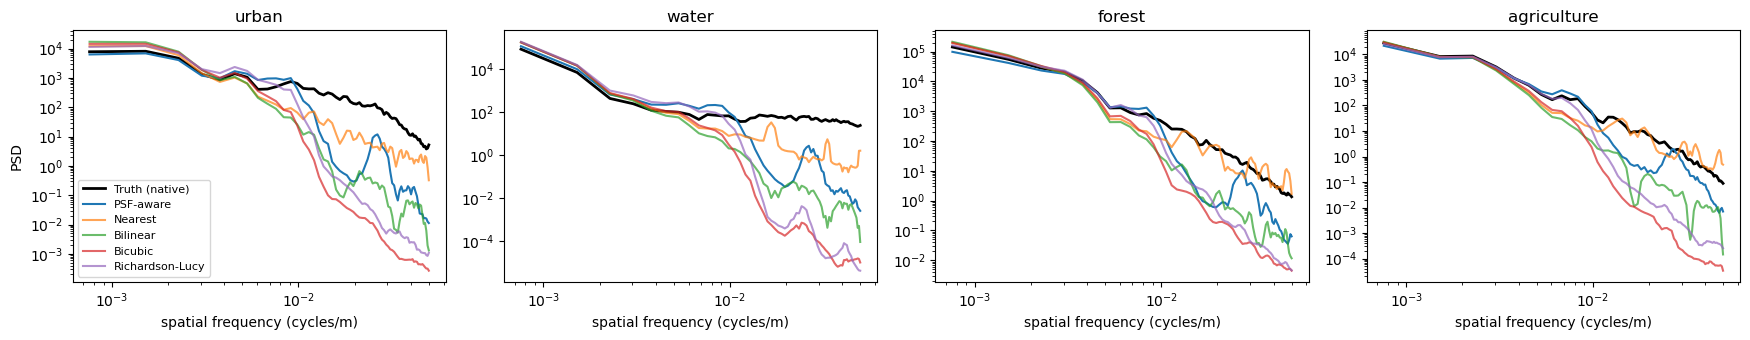

In [33]:
def plot_spectra(force=False):
    scenes = list(benchmark_coordinates.keys())
    fig, axes = plt.subplots(1, len(scenes), figsize=(4.4 * len(scenes), 3.5))
    if len(scenes) == 1:
        axes = [axes]

    for ax, scene in zip(axes, scenes):
        psf_d = reconstruct_psf_aware(scene, force=force)
        truth = crop_border(psf_d["truth10"])
        freq, psd_truth = psd1d_numpy(truth)
        ax.loglog(freq[1:], psd_truth[1:], label="Truth (native)", color="black", lw=2)

        _, psd_psf = psd1d_numpy(crop_border(psf_d["reconstructed10"]))
        ax.loglog(freq[1:], psd_psf[1:], label="PSF-aware")

        for method in CLASSICAL_METHODS:
            cl = reconstruct_classical(scene, method=method, force=force)
            _, psd_cl = psd1d_numpy(crop_border(cl["reconstructed10"]))
            ax.loglog(freq[1:], psd_cl[1:], label=CLASSICAL_LABELS[method], alpha=0.7)

        rl = reconstruct_richardson_lucy(scene, force=force)
        _, psd_rl = psd1d_numpy(crop_border(rl["reconstructed10"]))
        ax.loglog(freq[1:], psd_rl[1:], label="Richardson-Lucy", alpha=0.7)

        ax.set_title(scene)
        ax.set_xlabel("spatial frequency (cycles/m)")
        if scene == scenes[0]:
            ax.set_ylabel("PSD")
            ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "real_groundtruth_downscale_spectra.pdf", dpi=200)
    plt.show()


plot_spectra(force=False)


### Figure -- RMSE summary

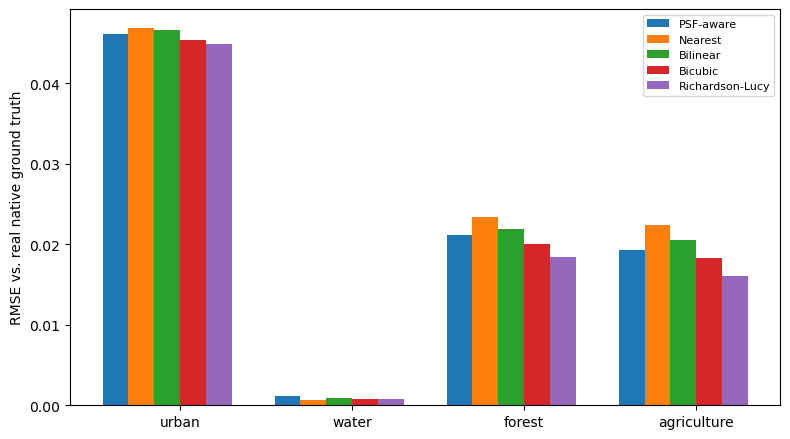

In [34]:
def plot_rmse_summary(df):
    labels = {
        "psf_aware": "PSF-aware",
        "classical_nearest": "Nearest",
        "classical_linear": "Bilinear",
        "classical_cubic": "Bicubic",
        "richardson_lucy": "Richardson-Lucy",
    }
    methods = list(labels.keys())
    scenes = list(benchmark_coordinates.keys())

    fig, ax = plt.subplots(figsize=(8, 4.5))
    width = 0.15
    x = np.arange(len(scenes))
    for i, m in enumerate(methods):
        vals = [df[(df["scene"] == s) & (df["method"] == m)]["rmse"].mean() for s in scenes]
        ax.bar(x + (i - len(methods) / 2) * width, vals, width, label=labels[m])
    ax.set_xticks(x)
    ax.set_xticklabels(scenes)
    ax.set_ylabel("RMSE vs. real native ground truth")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "real_groundtruth_downscale_rmse_summary.pdf", dpi=200)
    plt.show()


plot_rmse_summary(metrics_df)


## Notes and caveats

- **What this notebook does that the rest of the paper does not**: every
  number here is computed against a real, unsynthesized Sentinel-2 patch
  (`img_native`). Neither the round trip (no reference at all) nor the
  controlled Esri experiment (synthetic reference, matched degradation
  kernel) can make that claim.
- **What it does not establish**: there is no real 60 m Sentinel-2 B04 to
  compare `img_coarse` against, so this is still a *simulated* degradation
  of real data, not two independently acquired sensors. The degradation
  pipeline (`DEGRADE_FWHM_M`, `BLOCK`) is a modelling choice, documented and
  configurable at the top of the notebook, not a measured instrument
  response -- treat the absolute RMSE numbers as method comparisons under
  one specific, reasonable degradation, not as a universal recovery-rate
  claim.
- **The resolution gap and target level matter a lot**: the first version of
  this notebook (`BLOCK=2`, `HEALPIX_LEVEL=20`, see the title cell's
  revision note) made the PSF-aware method the *worst* of five methods on
  real data, contradicting its own reconstructed images and spectra, which
  looked good on visual inspection. The diagnosis was that a mild 2x
  degradation combined with a target grid ~10x finer than the coarse pixel
  asked the operator to extrapolate detail well past what a controlled
  partial restoration can support -- a mismatch between the test design and
  the method's actual operating regime, not evidence against the method
  itself. `BLOCK` and `HEALPIX_LEVEL` are the two constants that control
  this; if results still look implausible for your use case, check the
  printed cell-size line in the configuration cell first.
- **Deliberate PSF mismatch, now shape-consistent**: `RECON_FWHM_M`
  (assumed by the reconstruction operator and by Richardson-Lucy) is not fit
  to `DEGRADE_FWHM_M` (the true degradation) -- a genuine width mismatch,
  orthogonal to the resolution-gap issue above, so any recovery seen here is
  not an artefact of the operator knowing the exact generating process. An
  earlier version also made this a *shape* mismatch (Gaussian blur +
  block-average vs. the operator's pure circular Gaussian), which
  structurally disadvantaged the PSF-aware method regardless of tuning --
  see the title cell's second revision note. The true degradation kernel is
  now a plain circular Gaussian (blur, then point-sample/decimate, not
  block-average), so the remaining mismatch is only in width.
- **Border cropping**: `BORDER_CROP_PX` excludes a margin from every metric
  to avoid conflating genuine reconstruction quality with edge effects from
  blur padding and partially-supported HEALPix cells at the patch boundary.
  It does not affect the reconstructions themselves, only the evaluation.
- **Cache invalidation**: every intermediate `.npz` cache filename embeds
  `BLOCK`, `HEALPIX_LEVEL`, and `RECON_FWHM_M` (`_cache_suffix()`), so
  changing any of them always recomputes rather than silently reusing a
  stale result from a different configuration.
- **Extending this notebook**: a natural follow-up is sweeping
  `HEALPIX_LEVEL` (e.g. 16 vs. 17 vs. 18) and `RECON_FWHM_M` at fixed
  `BLOCK`, to trace out a sensitivity curve against a *real* reference --
  the real-data analogue of the paper's synthetic +-50% PSF-mismatch arms.
